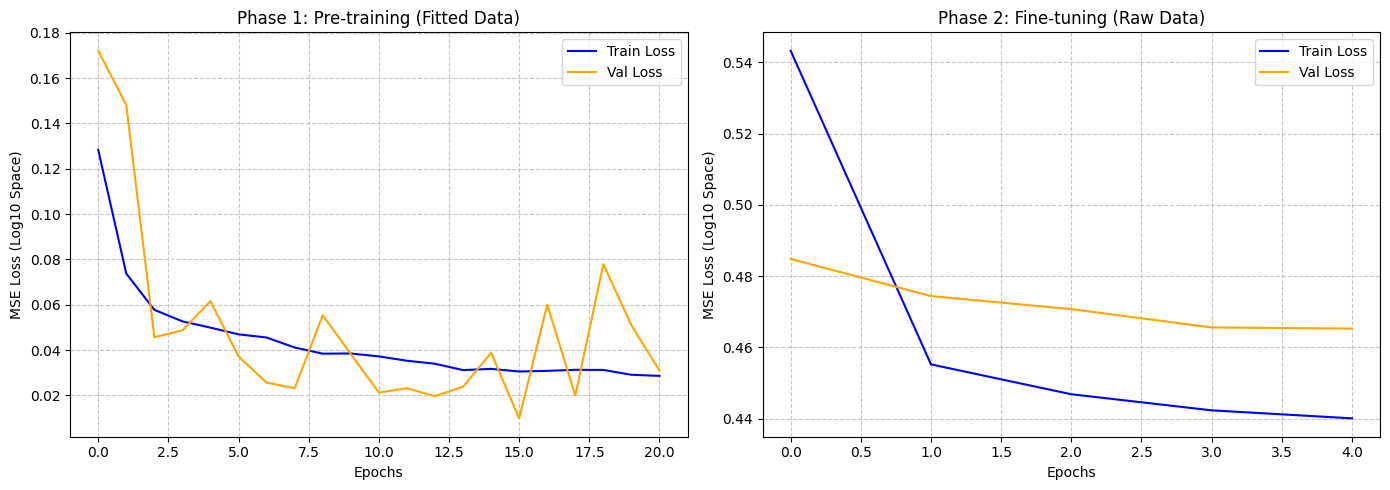

In [1]:
import joblib
import matplotlib.pyplot as plt

# Load the saved histories
history_fit = joblib.load('pretraining_history.joblib')
history_raw = joblib.load('fine_tuning_history.joblib')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Phase 1 (Fitted Data)
ax1.plot(history_fit['loss'], label='Train Loss', color='blue')
ax1.plot(history_fit['val_loss'], label='Val Loss', color='orange')
ax1.set_title('Phase 1: Pre-training (Fitted Data)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('MSE Loss (Log10 Space)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Plot Phase 2 (Raw Data)
ax2.plot(history_raw['loss'], label='Train Loss', color='blue')
ax2.plot(history_raw['val_loss'], label='Val Loss', color='orange')
ax2.set_title('Phase 2: Fine-tuning (Raw Data)')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('MSE Loss (Log10 Space)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

I0000 00:00:1776247587.342627  386788 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776247587.417027  386788 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776247588.372007  386788 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step


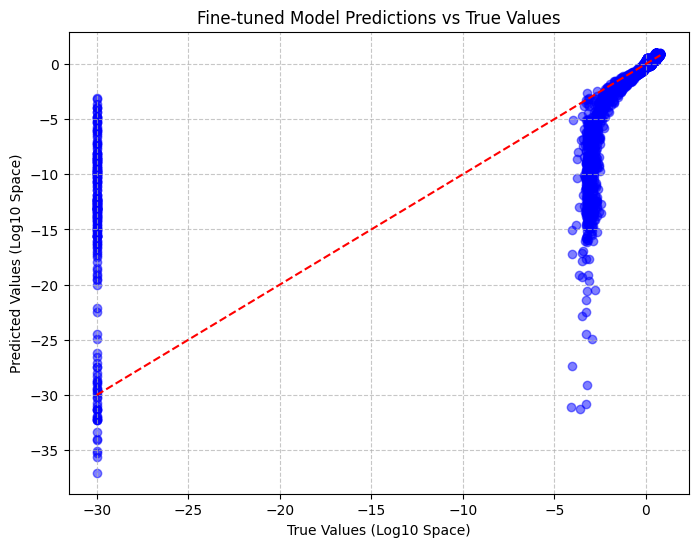

3068/3068 ━━━━━━━━━━━━━━━━━━━━ 2s 628us/step


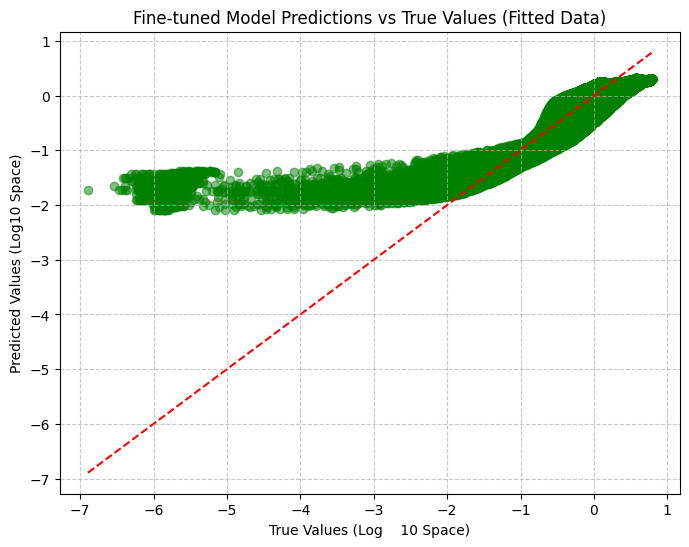

In [2]:
import numpy as np
import pickle

train_test_data = np.load('train_test_data.npz')
scalerXraw = pickle.load(open('scalerXraw.pkl', 'rb'))
scaleryraw = pickle.load(open('scaleryraw.pkl', 'rb'))
scalerXfit = pickle.load(open('scalerXfit.pkl', 'rb'))
scaleryfit = pickle.load(open('scaleryfit.pkl', 'rb'))

Xraw_selected_train = train_test_data['Xraw_selected_train']
Xraw_selected_train_scaled = scalerXraw.transform(Xraw_selected_train)  
Xraw_selected_test = train_test_data['Xraw_selected_test']
Xraw_selected_test_scaled = scalerXraw.transform(Xraw_selected_test)

yraw_selected_train = train_test_data['yraw_selected_train']
yraw_selected_train_scaled = scaleryraw.transform(yraw_selected_train.reshape(-1, 1))
yraw_selected_test = train_test_data['yraw_selected_test']
yraw_selected_test_scaled = scaleryraw.transform(yraw_selected_test.reshape(-1, 1))

Xfit_selected_train = train_test_data['Xfit_selected_train']
Xfit_selected_train_scaled = scalerXfit.transform(Xfit_selected_train)
Xfit_selected_test = train_test_data['Xfit_selected_test']
Xfit_selected_test_scaled = scalerXfit.transform(Xfit_selected_test)    

yfit_selected_train = train_test_data['yfit_selected_train']
yfit_selected_train_scaled = scaleryfit.transform(yfit_selected_train.reshape(-1, 1))
yfit_selected_test = train_test_data['yfit_selected_test']
yfit_selected_test_scaled = scaleryfit.transform(yfit_selected_test.reshape(-1, 1)) 

fine_tuned_model = joblib.load('fine_tuned_model.joblib')
predictions_scaled = fine_tuned_model.predict(Xraw_selected_test_scaled)
predictions = scaleryraw.inverse_transform(predictions_scaled.reshape(-1, 1))
plt.figure(figsize=(8, 6))
plt.scatter(yraw_selected_test, predictions, color='blue', alpha=0.5)
plt.plot([yraw_selected_test.min(), yraw_selected_test.max()], [yraw_selected_test.min(), yraw_selected_test.max()], 'r--')
plt.xlabel('True Values (Log10 Space)')
plt.ylabel('Predicted Values (Log10 Space)')
plt.title('Fine-tuned Model Predictions vs True Values')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
predictions_scaled_fit = fine_tuned_model.predict(Xfit_selected_test_scaled)
predictions_fit = scaleryfit.inverse_transform(predictions_scaled_fit.reshape(-1, 1))
plt.figure(figsize=(8, 6))
plt.scatter(yfit_selected_test, predictions_fit, color='green', alpha=0.5)
plt.plot([yfit_selected_test.min(), yfit_selected_test.max()], [yfit_selected_test.min(), yfit_selected_test.max()], 'r--')
plt.xlabel('True Values (Log    10 Space)')
plt.ylabel('Predicted Values (Log10 Space)')
plt.title('Fine-tuned Model Predictions vs True Values (Fitted Data)')          
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()